In [1]:
# Imports
import tensorflow as tf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

2024-06-19 20:17:16.286159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
df = pd.read_csv("output/training_data.csv")
df

,SALE DATE,BLOCK,LOT,YEAR BUILT,ZIP CODE,SALE PRICE
0,2015-10-22,376,24,1900,10009,3775000
1,2015-06-24,377,66,1899,10009,2900000
2,2015-06-15,399,1101,1955,10009,6995000
3,2015-11-17,373,16,1899,10009,20000000
4,2015-02-05,376,7,1900,10009,14550000
...,...,...,...,...,...,...
263295,2014-04-22,2180,1251,2003,10033,825000
263296,2014-06-04,2180,1252,2003,10033,740000
263297,2014-10-03,2180,1265,2003,10033,840000
263298,2014-01-14,2180,1204,2003,10033,30000


In [62]:

# Convert Pandas DataFrame to NumPy arrays
COL_SALE_DATE = 'SALE DATE'
df[COL_SALE_DATE] = pd.to_datetime(df[COL_SALE_DATE], errors='coerce')
# Extract date and time components
df['year'] = df[COL_SALE_DATE].dt.year
df['month'] = df[COL_SALE_DATE].dt.month
df['day'] = df[COL_SALE_DATE].dt.day

# X = df[['year', 'month', 'day',	'BLOCK', 'LOT',	'YEAR BUILT','ZIP CODE']].values  # Features
X = df[['year', 'month', 'BLOCK', 'LOT', 'YEAR BUILT']].values  # Features
# X = df[[COL_SALE_DATE,	'BLOCK',	'LOT']].values  # Features
y = df['SALE PRICE'].values.reshape(-1, 1)   # Target




In [63]:
X_train = X
m, n = X_train.shape
n

5

In [66]:
# Create a linear regression model with two input features
model = tf.keras.Sequential([
    # tf.keras.layers.Input(shape=(5,), name="input_layer"),  # Input shape matches the number of features
    tf.keras.layers.Dense( units=1, input_shape=(n,), activation='linear', name="output_layer")
])

# Compile the model
# model.compile(optimizer='sgd',  # Stochastic Gradient Descent
#               loss='mean_squared_error')

model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(0.01),
)


# Display the model summary
model.summary()


Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 output_layer (Dense)        (None, 1)                 6         
                                                                 
Total params: 6
Trainable params: 6
Non-trainable params: 0
_________________________________________________________________


In [67]:
# Train the model
history = model.fit(X_train, y, epochs=10, verbose=1)



Epoch 1/10
8229/8229 [==============================] - 5s 541us/step - loss: 309400283643904.0000
Epoch 2/10
8229/8229 [==============================] - 4s 508us/step - loss: 308705337802752.0000
Epoch 3/10
8229/8229 [==============================] - 4s 511us/step - loss: 308167225376768.0000
Epoch 4/10
8229/8229 [==============================] - 4s 506us/step - loss: 307759773908992.0000
Epoch 5/10
8229/8229 [==============================] - 4s 506us/step - loss: 307440201498624.0000
Epoch 6/10
8229/8229 [==============================] - 4s 512us/step - loss: 307198542479360.0000
Epoch 7/10
8229/8229 [==============================] - 5s 554us/step - loss: 307039360253952.0000
Epoch 8/10
8229/8229 [==============================] - 5s 548us/step - loss: 306920342683648.0000
Epoch 9/10
8229/8229 [==============================] - 4s 533us/step - loss: 306836221722624.0000
Epoch 10/10
8229/8229 [==============================] - 4s 523us/step - loss: 306765388316672.0000


In [68]:
tf.debugging.disable_traceback_filtering()

# Make predictions for new data
X_new = X_train[0]
X_new = X_new.reshape(1,n)
predictions = model.predict(X_new)
X_new


# # Display the predictions
# print("Predictions:")
# print(predictions)

1/1 [==============================] - 0s 37ms/step


array([[2015,   10,  376,   24, 1900]])

In [69]:
print(predictions)
print(y[0])
print(model.layers[0].get_weights())

[[1096268.9]]
[3775000]
[array([[264.17935],
       [215.50427],
       [253.31244],
       [260.90448],
       [242.11636]], dtype=float32), array([264.1106], dtype=float32)]


In [81]:

# Assuming df is your DataFrame and 'target' is your target column
df_sample = df.sample(n=100)
# Split the data into features and target columns
features = df_sample[['year', 'month', 'BLOCK', 'LOT', 'YEAR BUILT']].values
target = df_sample['SALE PRICE'].(1,)
# Use the sampled data to compare predictions vs ground truth
predictions = model.predict(features)
accuracy = accuracy_score(target, predictions)
print("Accuracy:",predictions, target)

AttributeError: 'Series' object has no attribute 'reshape'

TypeError: only size-1 arrays can be converted to Python scalars

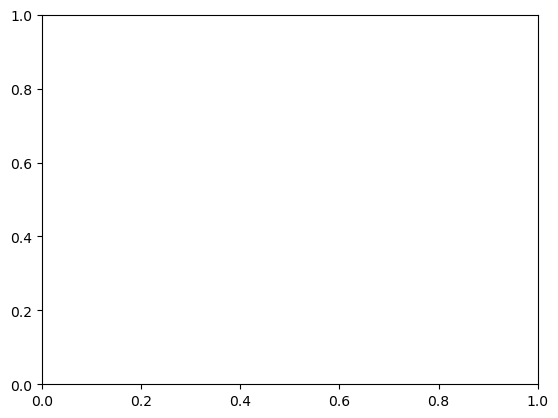

In [78]:

# Plot the predictions vs ground truth
plt.bar(target, predictions)
plt.xlabel("Ground Truth")
plt.ylabel("Predictions")
plt.title("Predictions vs Ground Truth")
plt.show()